In [1]:
# Выполнил Трифонов Дмитрий Сергеевич, 12-25РПм, 1 курс, Программная инженерия

# Практикум 2.2 — Геометрия и градиентный спуск
## Цель работы
Освоить геометрический смысл скалярного произведения и линейных преобразований, реализовать градиентный спуск для 1D и 2D функций, использовать TensorFlow GradientTape для вычисления градиента.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## Задание 1: Геометрия (dot, угол, поворот)

In [3]:
a = np.array([1., 0.])
b = np.array([0.5, np.sqrt(3)/2])

dot = np.dot(a, b)
cos_theta = dot / (np.linalg.norm(a) * np.linalg.norm(b))
theta = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

phi = np.radians(30)
R = np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])
a_rot = R @ a

print(f'dot={dot:.3f}, theta≈{theta:.1f}°')
print('a_rot:', a_rot)

dot=0.500, theta≈60.0°
a_rot: [0.8660254 0.5      ]


## Задание 2: Градиентный спуск 1D

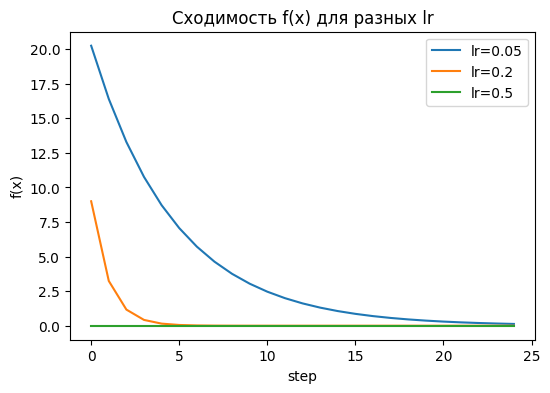

In [4]:
def f(x):
    return (x-3)**2

x = 8.0
learning_rates = [0.05, 0.2, 0.5]

plt.figure(figsize=(6,4))
for lr in learning_rates:
    x_curr = x
    xs, fs = [], []
    for step in range(25):
        grad = 2*(x_curr-3)
        x_curr -= lr*grad
        xs.append(x_curr)
        fs.append(f(x_curr))
    plt.plot(fs, label=f'lr={lr}')
plt.title('Сходимость f(x) для разных lr')
plt.xlabel('step')
plt.ylabel('f(x)')
plt.legend()
plt.show()

## Задание 3: Градиентный спуск 2D

00: w=[ 2.6 -4.4], f(w)=14.080000
01: w=[ 2.28 -3.44], f(w)=5.785600
02: w=[ 2.024 -2.864], f(w)=2.541568
03: w=[ 1.8192 -2.5184], f(w)=1.208566
04: w=[ 1.65536 -2.31104], f(w)=0.622988
05: w=[ 1.524288 -2.186624], f(w)=0.344535
06: w=[ 1.4194304 -2.1119744], f(w)=0.200998
07: w=[ 1.33554432 -2.06718464], f(w)=0.121618
08: w=[ 1.26843546 -2.04031078], f(w)=0.075308
09: w=[ 1.21474836 -2.02418647], f(w)=0.047287
10: w=[ 1.17179869 -2.01451188], f(w)=0.029936
11: w=[ 1.13743895 -2.00870713], f(w)=0.019041
12: w=[ 1.10995116 -2.00522428], f(w)=0.012144
13: w=[ 1.08796093 -2.00313457], f(w)=0.007757
14: w=[ 1.07036874 -2.00188074], f(w)=0.004959
15: w=[ 1.056295   -2.00112844], f(w)=0.003172
16: w=[ 1.045036   -2.00067707], f(w)=0.002029
17: w=[ 1.0360288  -2.00040624], f(w)=0.001298
18: w=[ 1.02882304 -2.00024374], f(w)=0.000831
19: w=[ 1.02305843 -2.00014625], f(w)=0.000532
20: w=[ 1.01844674 -2.00008775], f(w)=0.000340
21: w=[ 1.0147574  -2.00005265], f(w)=0.000218
22: w=[ 1.01180592 -2

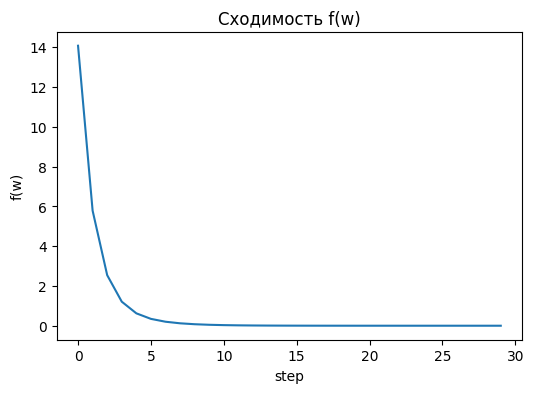

In [5]:
def f2(w):
    return (w[0]-1)**2 + 2*(w[1]+2)**2

w = np.array([3.0, -6.0])
lr = 0.1
vals = []
for step in range(30):
    grad = np.array([2*(w[0]-1), 4*(w[1]+2)])
    w -= lr * grad
    vals.append(f2(w))
    print(f'{step:02d}: w={w}, f(w)={f2(w):.6f}')

plt.figure(figsize=(6,4))
plt.plot(vals)
plt.title('Сходимость f(w)')
plt.xlabel('step')
plt.ylabel('f(w)')
plt.show()

## Задание 4 (опционально): TensorFlow GradientTape

In [6]:
# import tensorflow as tf
# x_tf = tf.Variable(5.0)
# with tf.GradientTape() as tape:
#     y = (x_tf-3.0)**2
# dy_dx = tape.gradient(y, x_tf)
# print('dy/dx:', dy_dx.numpy())

## Выводы
- Скалярное произведение позволяет вычислить угол между векторами
- Матрица поворота корректно поворачивает вектор
- Влияние шага обучения на сходимость 1D функции очевидно: слишком большой lr вызывает расходимость
- В 2D функции координата с большим градиентом сходится быстрее, как видно по w[1]